# ATM CashFlow Analysis Pipeline

This notebook implements an end-to-end forecasting pipeline for ATM daily cash withdrawals using the **NN5 competition dataset**. 
The dataset contains daily withdrawal amounts from **111 ATMs** in the UK, spanning from March 1996 to May 1998.

**Pipeline Overview:**
1. Data Import
2. Data Cleaning & Reshaping
3. Exploratory Data Analysis
4. Feature Engineering
5. Feature Scaling
6. Train/Test Split
7. Model Training — ARIMA, SARIMAX, XGBoost, Random Forest
8. Evaluation & Model Comparison

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import ks_2samp
import holidays

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('deep')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Data Import

The NN5 dataset is stored in `.tsf` (time series format) — a structured text format where each line represents one ATM's complete withdrawal history. 
The parser below extracts series names, start dates, and daily values, then constructs a wide-format DataFrame with dates as rows and ATMs as columns.

In [14]:
def load_tsf_custom(file_path):
    new_data = {}
    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()
            if not line or line.startswith('#') or line.startswith('@'):
                continue
            parts = line.split(':')
            if len(parts) >= 3:
                series_name = parts[0]
                start_date = parts[1].split(' ')[0]
                values_str = parts[2]
                values = [float(val) if val != '?' else np.nan for val in values_str.split(',')]
                new_data[series_name] = values
    df = pd.DataFrame(new_data)
    df.index = pd.date_range(start=start_date, periods=len(df), freq='D')
    return df

df_nn5 = load_tsf_custom('nn5_daily_dataset_without_missing_values.tsf')
print(f'Dataset shape: {df_nn5.shape} — {df_nn5.shape[1]} ATMs, {df_nn5.shape[0]} daily observations')
print(f'Date range: {df_nn5.index.min()} to {df_nn5.index.max()}')
df_nn5.head()

Dataset shape: (791, 111) — 111 ATMs, 791 daily observations
Date range: 1996-03-18 00:00:00 to 1998-05-17 00:00:00


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,...,T102,T103,T104,T105,T106,T107,T108,T109,T110,T111
1996-03-18,13.407029,11.550454,5.640590,13.180272,9.778912,9.240363,14.937642,2.891156,7.341270,10.289116,...,12.910998,3.670635,14.200680,9.778912,7.695578,8.857710,9.297052,10.416667,11.635488,8.337717
1996-03-19,14.725057,13.591270,14.399093,8.446712,10.813492,11.635488,16.284014,12.358277,9.155329,12.712585,...,15.447846,3.557256,7.128685,11.564626,5.541383,11.380385,12.429138,14.923469,10.586735,9.876381
1996-03-20,20.564059,15.036848,24.418934,19.515306,21.612812,12.103175,16.666667,16.383220,10.586735,14.441610,...,20.372732,4.846939,24.900794,13.803855,16.312358,11.777211,13.251134,25.864512,12.570862,16.320358
1996-03-21,34.708050,21.570295,28.784014,28.883220,38.520408,21.414399,23.568594,30.158730,12.500000,19.401927,...,26.296769,7.086168,26.261338,23.341837,23.951247,18.820862,24.815760,37.996032,17.517007,22.553919
1996-03-22,26.629819,19.444444,20.620748,19.472789,24.744898,24.674036,26.303855,31.179138,7.157029,21.541950,...,33.056973,5.357143,32.893991,23.129252,24.064626,24.305556,19.231859,33.290816,24.291383,18.095739


## 2. Data Cleaning & Reshaping

The raw data is in **wide format** (one column per ATM). For panel-data modeling, we reshape it into **long format** with three columns: `Date`, `ATM_ID`, and `Withdrawal`. 
Chronological sorting within each ATM group is critical for time-series feature engineering.

In [15]:
df_long = df_nn5.reset_index().melt(id_vars='index', var_name='ATM_ID', value_name='Withdrawal')
df_long.rename(columns={'index': 'Date'}, inplace=True)
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long = df_long.sort_values(by=['ATM_ID', 'Date']).reset_index(drop=True)

print(f'Reshaped data: {len(df_long)} rows')
print(f'Missing values: {df_long["Withdrawal"].isna().sum()}')
display(df_long.head())
display(df_long.describe())

Reshaped data: 87801 rows
Missing values: 0


,Date,ATM_ID,Withdrawal
0,1996-03-18,T1,13.407029
1,1996-03-19,T1,14.725057
2,1996-03-20,T1,20.564059
3,1996-03-21,T1,34.708050
4,1996-03-22,T1,26.629819


,Date,Withdrawal
count,87801,87801.000000
mean,1997-04-17 00:00:00.000000128,18.403535
min,1996-03-18 00:00:00,0.000000
25%,1996-10-01 00:00:00,11.933107
50%,1997-04-17 00:00:00,16.439909
75%,1997-11-01 00:00:00,23.299320
max,1998-05-17 00:00:00,95.962651
std,NaN,9.717218


## 3. Exploratory Data Analysis

Before modeling, we examine the statistical properties of ATM withdrawals: distributions, weekly seasonality patterns, stationarity, and concept drift between early and late periods of the dataset.

### 3.1 Distribution of Daily Withdrawals

The histogram below shows the overall distribution of daily withdrawal amounts across all ATMs. 
This reveals the typical range of values and any skewness that might affect model performance.

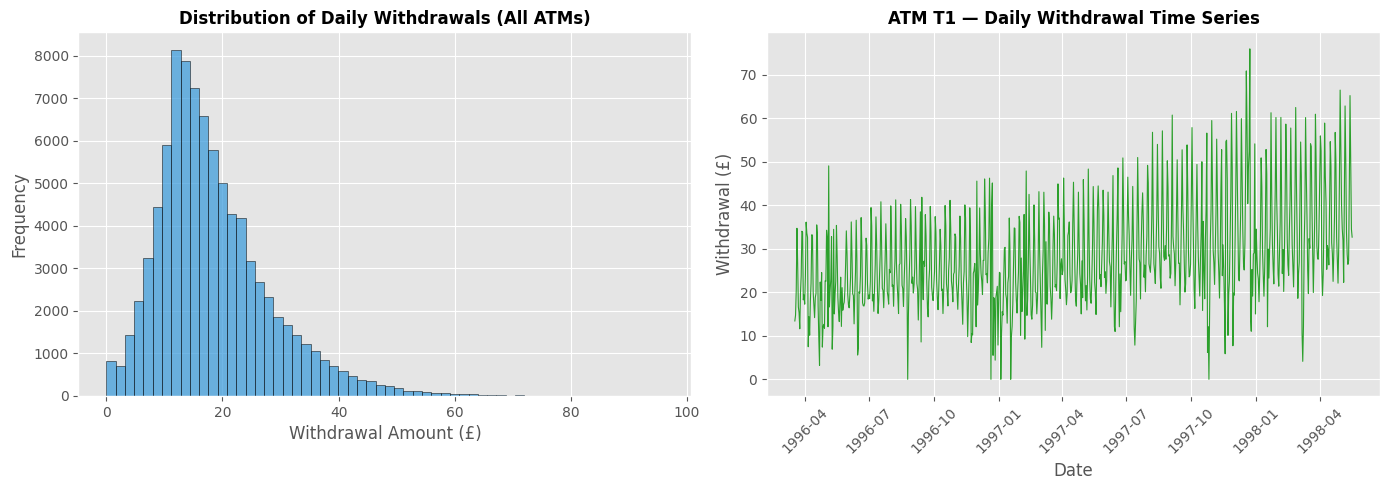

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_long['Withdrawal'], bins=60, edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_title('Distribution of Daily Withdrawals (All ATMs)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Withdrawal Amount (£)')
axes[0].set_ylabel('Frequency')

sample_atm = df_long[df_long['ATM_ID'] == 'T1'].set_index('Date')['Withdrawal']
axes[1].plot(sample_atm.index, sample_atm.values, linewidth=0.8, color='#2ca02c')
axes[1].set_title('ATM T1 — Daily Withdrawal Time Series', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Withdrawal (£)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3.2 Weekly Seasonality Pattern

ATM withdrawals exhibit strong weekly seasonality — Thursdays and Fridays typically see higher volumes (payday/weekend preparation), while early-week days are quieter.

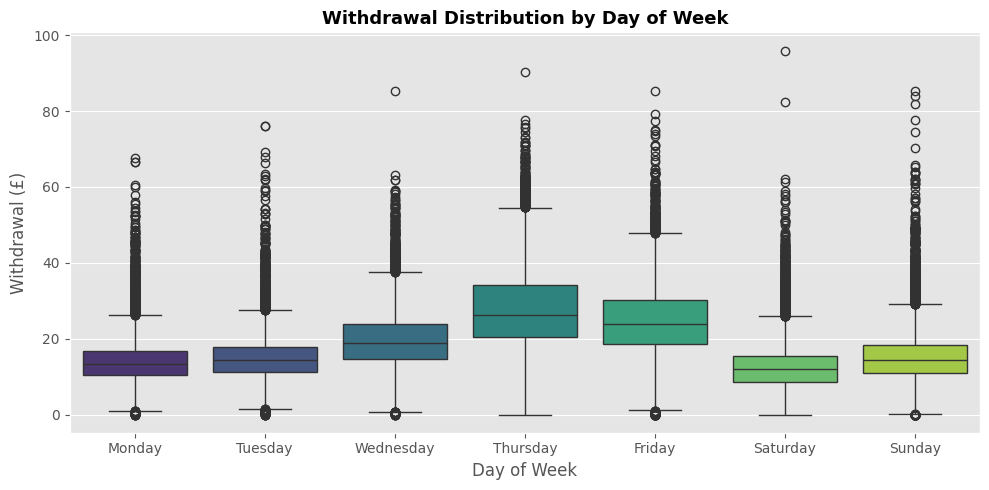

In [17]:
df_eda = df_long.copy()
df_eda['DayOfWeek'] = df_eda['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_eda, x='DayOfWeek', y='Withdrawal', order=day_order, palette='viridis')
plt.title('Withdrawal Distribution by Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Withdrawal (£)')
plt.tight_layout()
plt.show()

### 3.3 Time Series Decomposition

Seasonal decomposition of ATM T1 separates the time series into trend, seasonal, and residual components. The 7-day period captures weekly cycles.

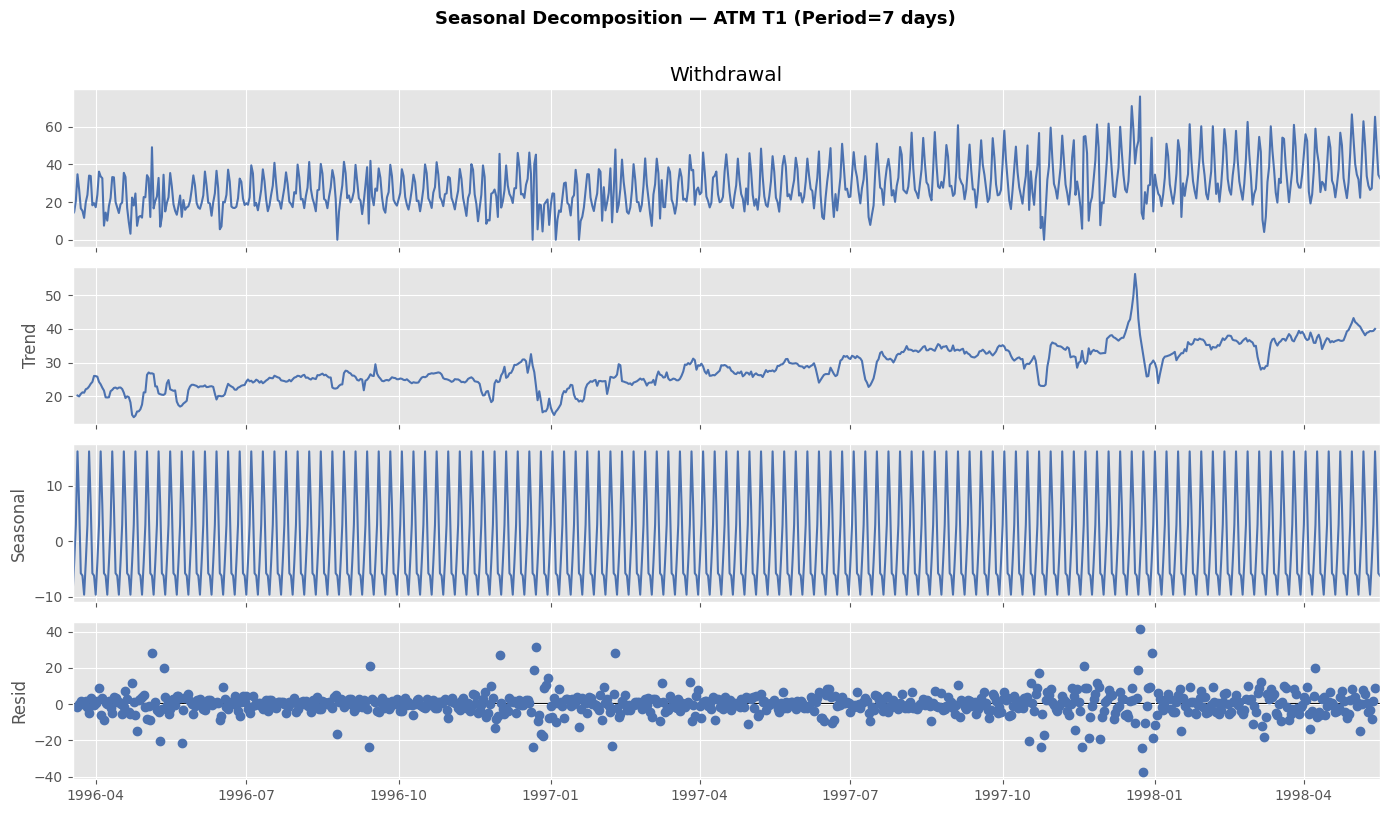

In [18]:
ts_t1 = df_long[df_long['ATM_ID'] == 'T1'].set_index('Date')['Withdrawal']
decomposition = seasonal_decompose(ts_t1, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Seasonal Decomposition — ATM T1 (Period=7 days)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Statistical Tests

Two diagnostic tests assess data quality for time-series modeling:
- **Augmented Dickey-Fuller (ADF)**: Tests for stationarity — a stationary series is easier to forecast.
- **Kolmogorov-Smirnov (K-S)**: Compares the first and second halves of the data to detect concept drift over time.

In [19]:
def run_diagnostics(df_test, atm_id='T1'):
    sample = df_test[df_test['ATM_ID'] == atm_id]['Withdrawal'].dropna()
    size = len(sample) // 2
    first_half, second_half = sample[:size], sample[size:]
    ks_stat, ks_p = ks_2samp(first_half, second_half)
    adf_stat, adf_p, _, _, crit, _ = adfuller(sample)

    print(f'--- Diagnostic Report for {atm_id} ---')
    print(f'\n1. K-S Test (Concept Drift): p-value = {ks_p:.5f}')
    print(f'   {"FAIL — significant distribution shift" if ks_p < 0.05 else "PASS — stable distribution"}')
    print(f'\n2. ADF Test (Stationarity): p-value = {adf_p:.5f}')
    print(f'   Test stat: {adf_stat:.3f} vs 5% critical: {crit["5%"]:.3f}')
    print(f'   {"PASS — stationary" if adf_p < 0.05 else "FAIL — non-stationary"}')

run_diagnostics(df_long, 'T1')

--- Diagnostic Report for T1 ---

1. K-S Test (Concept Drift): p-value = 0.00000
   FAIL — significant distribution shift

2. ADF Test (Stationarity): p-value = 0.42180
   Test stat: -1.718 vs 5% critical: -2.865
   FAIL — non-stationary


## 4. Feature Engineering

Now we expanded feature set for maximum predictive power:
- **Target transformation**: Day-over-day differencing (`Withdrawal_Delta`)
- **Calendar features**: DayOfWeek, Is_Weekend, Month, DayOfMonth, PayDay, UK Holiday
- **Lag features**: 1, 7, 14, 21, and 28-day lags to capture daily, weekly, and monthly cycles
- **Rolling statistics**: 7/14/28-day rolling means, 7-day rolling std and median
- **Exponential weighted means**: 7-day and 14-day EWM (weights recent observations more heavily)
- **Derived features**: Same-day-last-week, week-over-week change
- **Fourier terms**: Sin/cos encoding for weekly and monthly cycles

In [20]:
df_features = df_long.copy()

df_features['Withdrawal_Delta'] = df_features.groupby('ATM_ID')['Withdrawal'].diff()

df_features['DayOfWeek'] = df_features['Date'].dt.dayofweek
df_features['Is_Weekend'] = df_features['DayOfWeek'].isin([5, 6]).astype(int)
df_features['Month'] = df_features['Date'].dt.month
df_features['DayOfMonth'] = df_features['Date'].dt.day

uk_holidays = holidays.UK(years=[1996, 1997, 1998])
df_features['Is_UK_Holiday'] = df_features['Date'].apply(lambda x: 1 if x in uk_holidays else 0)
df_features['PayDay'] = ((df_features['DayOfMonth'] <= 3) | (df_features['DayOfMonth'].isin([30, 31]))) & (df_features['Is_UK_Holiday'] == 0)
df_features['PayDay'] = df_features['PayDay'].astype(int)

df_features['Withdrawal_Lag_1'] = df_features.groupby('ATM_ID')['Withdrawal'].shift(1)
df_features['Withdrawal_Lag_7'] = df_features.groupby('ATM_ID')['Withdrawal'].shift(7)
df_features['Withdrawal_Lag_14'] = df_features.groupby('ATM_ID')['Withdrawal'].shift(14)
df_features['Withdrawal_Lag_21'] = df_features.groupby('ATM_ID')['Withdrawal'].shift(21)
df_features['Withdrawal_Lag_28'] = df_features.groupby('ATM_ID')['Withdrawal'].shift(28)

df_features['Rolling_Mean_7d'] = df_features.groupby('ATM_ID')['Withdrawal'].transform(lambda x: x.shift(1).rolling(7).mean())
df_features['Rolling_Mean_14d'] = df_features.groupby('ATM_ID')['Withdrawal'].transform(lambda x: x.shift(1).rolling(14).mean())
df_features['Rolling_Mean_28d'] = df_features.groupby('ATM_ID')['Withdrawal'].transform(lambda x: x.shift(1).rolling(28).mean())
df_features['Rolling_Std_7d'] = df_features.groupby('ATM_ID')['Withdrawal'].transform(lambda x: x.shift(1).rolling(7).std())
df_features['Rolling_Median_7d'] = df_features.groupby('ATM_ID')['Withdrawal'].transform(lambda x: x.shift(1).rolling(7).median())
df_features['EWM_7d'] = df_features.groupby('ATM_ID')['Withdrawal'].transform(lambda x: x.shift(1).ewm(span=7).mean())
df_features['EWM_14d'] = df_features.groupby('ATM_ID')['Withdrawal'].transform(lambda x: x.shift(1).ewm(span=14).mean())

df_features['Same_Day_Last_Week'] = df_features['Withdrawal_Lag_7']
df_features['Week_Over_Week_Change'] = df_features['Withdrawal_Lag_1'] - df_features['Withdrawal_Lag_7']

df_features['Weekly_Sin'] = np.sin(2 * np.pi * df_features['DayOfWeek'] / 7)
df_features['Weekly_Cos'] = np.cos(2 * np.pi * df_features['DayOfWeek'] / 7)
df_features['Monthly_Sin'] = np.sin(2 * np.pi * df_features['DayOfMonth'] / 30.5)
df_features['Monthly_Cos'] = np.cos(2 * np.pi * df_features['DayOfMonth'] / 30.5)

df_features['ATM_ID'] = df_features['ATM_ID'].astype('category')

df_model_ready = df_features.dropna().reset_index(drop=True)
print(f'Feature engineering complete. Rows ready: {len(df_model_ready)}')
print(f'Total features: {len(df_model_ready.columns) - 3}')
display(df_model_ready.head(3))

Feature engineering complete. Rows ready: 84693
Total features: 25


,Date,ATM_ID,Withdrawal,Withdrawal_Delta,DayOfWeek,Is_Weekend,Month,DayOfMonth,Is_UK_Holiday,PayDay,...,Rolling_Std_7d,Rolling_Median_7d,EWM_7d,EWM_14d,Same_Day_Last_Week,Week_Over_Week_Change,Weekly_Sin,Weekly_Cos,Monthly_Sin,Monthly_Cos
0,1996-04-15,T1,14.172336,-2.962018,0,0,4,15,0,0,...,8.508725,20.011338,22.291921,22.459952,10.133220,7.001134,0.000000,1.000000,0.051479,-0.998674
1,1996-04-16,T1,18.764172,4.591837,1,0,4,16,0,0,...,7.669468,20.011338,20.261541,21.337236,17.913832,-3.741497,0.781831,0.623490,-0.153891,-0.988088
2,1996-04-17,T1,19.770408,1.006236,2,0,4,17,0,0,...,7.590570,20.011338,19.887132,20.989409,22.123016,-3.358844,0.974928,-0.222521,-0.352752,-0.935717


## 5. Feature Scaling

StandardScaler normalizes numeric features to zero mean and unit variance. This is applied **after** the train/test split to prevent data leakage — the scaler is fit only on training data.

## 6. Train/Test Split

For time-series data, we use a **chronological split** — the last 60 days serve as the test set. Random splitting would cause future data to leak into training.

- **Statistical models** (ARIMA/SARIMAX): Trained on multiple individual ATMs, then scores are aggregated.
- **ML models** (XGBoost/Random Forest): Trained as global models on all 111 ATMs simultaneously.

In [21]:
split_date = df_model_ready['Date'].max() - pd.Timedelta(days=60)

train_df = df_model_ready[df_model_ready['Date'] < split_date]
test_df = df_model_ready[df_model_ready['Date'] >= split_date]

features = [
    'ATM_ID', 'DayOfWeek', 'Is_Weekend', 'Month', 'DayOfMonth',
    'Is_UK_Holiday', 'PayDay',
    'Withdrawal_Lag_1', 'Withdrawal_Lag_7', 'Withdrawal_Lag_14',
    'Withdrawal_Lag_21', 'Withdrawal_Lag_28',
    'Rolling_Mean_7d', 'Rolling_Mean_14d', 'Rolling_Mean_28d',
    'Rolling_Std_7d', 'Rolling_Median_7d',
    'EWM_7d', 'EWM_14d',
    'Same_Day_Last_Week', 'Week_Over_Week_Change',
    'Weekly_Sin', 'Weekly_Cos', 'Monthly_Sin', 'Monthly_Cos'
]
target = 'Withdrawal_Delta'

numeric_features = [f for f in features if f != 'ATM_ID']

scaler = StandardScaler()
train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()
train_df_scaled[numeric_features] = scaler.fit_transform(train_df[numeric_features])
test_df_scaled[numeric_features] = scaler.transform(test_df[numeric_features])

X_train = train_df_scaled[features]
y_train = train_df_scaled[target]
X_test = test_df_scaled[features]
y_test_delta = test_df_scaled[target]

print(f'Training set: {len(train_df)} rows')
print(f'Test set:     {len(test_df)} rows')
print(f'Features:     {len(features)}')

Training set: 77922 rows
Test set:     6771 rows
Features:     25


## 7. Model Training & Prediction

We train four models in order of complexity:
1. **ARIMA** — baseline with no seasonality awareness
2. **SARIMAX** — adds 7-day seasonal component
3. **XGBoost** — gradient-boosted global model across all ATMs
4. **Random Forest** — ensemble global model for comparison

For ARIMA/SARIMAX, we evaluate on a sample of ATMs and report the combined score.

### 7.1 ARIMA Baseline

ARIMA(1,1,1) uses only past values and errors for forecasting. It has **no awareness of weekly cycles**, so it tends to draw a flat line through weekend spikes. We train on multiple ATMs and aggregate the MAE.

In [22]:
sample_atms = ['T1', 'T25', 'T50', 'T75', 'T107']
arima_results = {}

for atm_id in sample_atms:
    ts = df_long[df_long['ATM_ID'] == atm_id].set_index('Date').sort_index()['Withdrawal'].dropna()
    split = ts.index.max() - pd.Timedelta(days=60)
    train_ts, test_ts = ts[ts.index < split], ts[ts.index >= split]
    y_log = np.log1p(train_ts)

    model = SARIMAX(y_log, order=(1,1,1), enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    fc = np.expm1(fit.forecast(steps=len(test_ts)))
    mae = mean_absolute_error(test_ts, fc)
    arima_results[atm_id] = {'actual': test_ts, 'predicted': fc, 'mae': mae}
    print(f'  ARIMA MAE ({atm_id}): £{mae:.2f}')

arima_combined_mae = np.mean([v['mae'] for v in arima_results.values()])
print(f'\nARIMA Combined MAE ({len(sample_atms)} ATMs): £{arima_combined_mae:.2f}')

  ARIMA MAE (T1): £10.91
  ARIMA MAE (T25): £6.15
  ARIMA MAE (T50): £8.91
  ARIMA MAE (T75): £6.22
  ARIMA MAE (T107): £6.98

ARIMA Combined MAE (5 ATMs): £7.83


### 7.2 SARIMAX — Seasonal ARIMA

SARIMAX(1,1,1)(1,1,1,7) adds a **7-day seasonal cycle** to the ARIMA framework. This captures the recurring weekly pattern of ATM withdrawals and should produce a significant improvement over the baseline.

In [23]:
sarimax_results = {}

for atm_id in sample_atms:
    ts = df_long[df_long['ATM_ID'] == atm_id].set_index('Date').sort_index()['Withdrawal'].dropna()
    split = ts.index.max() - pd.Timedelta(days=60)
    train_ts, test_ts = ts[ts.index < split], ts[ts.index >= split]
    y_log = np.log1p(train_ts)

    model = SARIMAX(y_log, order=(1,1,1), seasonal_order=(1,1,1,7),
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    fc = np.expm1(fit.forecast(steps=len(test_ts)))
    mae = mean_absolute_error(test_ts, fc)
    sarimax_results[atm_id] = {'actual': test_ts, 'predicted': fc, 'mae': mae}
    print(f'  SARIMAX MAE ({atm_id}): £{mae:.2f}')

sarimax_combined_mae = np.mean([v['mae'] for v in sarimax_results.values()])
print(f'\nSARIMAX Combined MAE ({len(sample_atms)} ATMs): £{sarimax_combined_mae:.2f}')

  SARIMAX MAE (T1): £5.84
  SARIMAX MAE (T25): £3.85
  SARIMAX MAE (T50): £5.68
  SARIMAX MAE (T75): £3.08
  SARIMAX MAE (T107): £3.71

SARIMAX Combined MAE (5 ATMs): £4.43


### 7.3 XGBoost — Optuna-Tuned Global Model

We use **Optuna** for Bayesian hyperparameter optimization. The objective minimizes 5-fold time-series cross-validation MAE. This finds optimal `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`, and regularization parameters.

Results : Best params: {'max_depth': 11, 'learning_rate': 0.015506649970209977, 'n_estimators': 700, 'subsample': 0.9449988505147582, 'colsample_bytree': 0.5012265561101736, 'min_child_weight': 8, 'reg_alpha': 9.879748736065544, 'reg_lambda': 0.004677733798019023}


In [25]:
!pip install optuna

  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [optuna]━━━━ 3/4 [optuna]]


In [26]:
import optuna
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 400, 1500, step=100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'random_state': 42,
        'enable_categorical': True
    }

    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = xgb.XGBRegressor(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = m.predict(X_val)
        scores.append(mean_absolute_error(y_val, pred))
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'Best CV MAE (delta): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

model_xgb = xgb.XGBRegressor(**study.best_params, random_state=42, enable_categorical=True)
model_xgb.fit(X_train, y_train)

test_xgb = test_df.copy()
test_xgb['Predicted_Delta'] = model_xgb.predict(X_test)
test_xgb['Predicted_Withdrawal'] = test_xgb['Withdrawal_Lag_1'] + test_xgb['Predicted_Delta']

xgb_global_mae = mean_absolute_error(test_xgb['Withdrawal'], test_xgb['Predicted_Withdrawal'])
print(f'\nXGBoost Tuned Global MAE (all 111 ATMs): £{xgb_global_mae:.2f}')

for atm_id in sample_atms:
    subset = test_xgb[test_xgb['ATM_ID'] == atm_id]
    mae = mean_absolute_error(subset['Withdrawal'], subset['Predicted_Withdrawal'])
    print(f'  XGBoost MAE ({atm_id}): £{mae:.2f}')

Best trial: 38. Best value: 4.81539: 100%|██████| 50/50 [18:10<00:00, 21.81s/it]


Best CV MAE (delta): 4.8154
Best params: {'max_depth': 11, 'learning_rate': 0.015506649970209977, 'n_estimators': 700, 'subsample': 0.9449988505147582, 'colsample_bytree': 0.5012265561101736, 'min_child_weight': 8, 'reg_alpha': 9.879748736065544, 'reg_lambda': 0.004677733798019023}

XGBoost Tuned Global MAE (all 111 ATMs): £3.36
  XGBoost MAE (T1): £4.83
  XGBoost MAE (T25): £3.33
  XGBoost MAE (T50): £5.84
  XGBoost MAE (T75): £3.07
  XGBoost MAE (T107): £3.26


### 7.4 Random Forest — Global Model

Random Forest provides an ensemble alternative to XGBoost. It is typically more robust to overfitting and doesn't require careful learning-rate tuning. Since `sklearn` doesn't natively support categorical features, we label-encode ATM_ID.

In [27]:
le = LabelEncoder()
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()
X_train_rf['ATM_ID'] = le.fit_transform(train_df['ATM_ID'])
X_test_rf['ATM_ID'] = le.transform(test_df['ATM_ID'])

model_rf = RandomForestRegressor(
    n_estimators=800, max_depth=15, min_samples_leaf=3,
    max_features=0.6, random_state=42, n_jobs=-1
)
model_rf.fit(X_train_rf, y_train)

test_rf = test_df.copy()
test_rf['Predicted_Delta'] = model_rf.predict(X_test_rf)
test_rf['Predicted_Withdrawal'] = test_rf['Withdrawal_Lag_1'] + test_rf['Predicted_Delta']

rf_global_mae = mean_absolute_error(test_rf['Withdrawal'], test_rf['Predicted_Withdrawal'])
print(f'Random Forest Global MAE (all 111 ATMs): £{rf_global_mae:.2f}')

for atm_id in sample_atms:
    subset = test_rf[test_rf['ATM_ID'] == atm_id]
    mae = mean_absolute_error(subset['Withdrawal'], subset['Predicted_Withdrawal'])
    print(f'  Random Forest MAE ({atm_id}): £{mae:.2f}')

Random Forest Global MAE (all 111 ATMs): £3.43
  Random Forest MAE (T1): £4.73
  Random Forest MAE (T25): £3.12
  Random Forest MAE (T50): £6.04
  Random Forest MAE (T75): £2.94
  Random Forest MAE (T107): £3.47


### 7.5 Weighted Ensemble — XGBoost + Random Forest

We blend the two best models using an optimized weight. The ensemble exploits the fact that XGBoost and Random Forest make different types of errors — combining them reduces overall prediction variance.

In [28]:
best_mae = float('inf')
best_w = 0.5
for w in np.arange(0.1, 0.95, 0.05):
    blended = w * test_xgb['Predicted_Withdrawal'].values + (1-w) * test_rf['Predicted_Withdrawal'].values
    mae = mean_absolute_error(test_df['Withdrawal'], blended)
    if mae < best_mae:
        best_mae = mae
        best_w = w

test_ensemble = test_df.copy()
test_ensemble['Predicted_Withdrawal'] = best_w * test_xgb['Predicted_Withdrawal'].values + (1-best_w) * test_rf['Predicted_Withdrawal'].values

ensemble_mae = mean_absolute_error(test_ensemble['Withdrawal'], test_ensemble['Predicted_Withdrawal'])
print(f'Optimal blend weight: XGBoost={best_w:.2f}, RF={1-best_w:.2f}')
print(f'Ensemble Global MAE (all 111 ATMs): £{ensemble_mae:.2f}')

for atm_id in sample_atms:
    subset = test_ensemble[test_ensemble['ATM_ID'] == atm_id]
    mae = mean_absolute_error(subset['Withdrawal'], subset['Predicted_Withdrawal'])
    print(f'  Ensemble MAE ({atm_id}): £{mae:.2f}')

Optimal blend weight: XGBoost=0.65, RF=0.35
Ensemble Global MAE (all 111 ATMs): £3.34
  Ensemble MAE (T1): £4.77
  Ensemble MAE (T25): £3.19
  Ensemble MAE (T50): £5.89
  Ensemble MAE (T75): £2.97
  Ensemble MAE (T107): £3.31


## 8. Model Evaluation & Comparison

We evaluate all models using four metrics:
- **R² (R-Squared)**: Proportion of variance explained (closer to 1.0 = better)
- **MAE (Mean Absolute Error)**: Average absolute prediction error in £
- **RMSE (Root Mean Squared Error)**: Penalizes large errors more heavily
- **MAPE (Mean Absolute Percentage Error)**: Percentage error, filtered to exclude near-zero actuals (< £1.0) to avoid division-by-zero distortions

In [29]:
def safe_mape(y_true, y_pred, threshold=1.0):
    mask = np.abs(y_true) > threshold
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calc_metrics(y_true, y_pred, name):
    y_t, y_p = np.array(y_true), np.array(y_pred)
    return {
        'Model': name,
        'R²': r2_score(y_t, y_p),
        'MAE (£)': mean_absolute_error(y_t, y_p),
        'RMSE (£)': np.sqrt(mean_squared_error(y_t, y_p)),
        'MAPE (%)': safe_mape(y_t, y_p)
    }

metrics = []
metrics.append(calc_metrics(test_xgb['Withdrawal'], test_xgb['Predicted_Withdrawal'], 'XGBoost (Tuned)'))
metrics.append(calc_metrics(test_rf['Withdrawal'], test_rf['Predicted_Withdrawal'], 'Random Forest'))
metrics.append(calc_metrics(test_ensemble['Withdrawal'], test_ensemble['Predicted_Withdrawal'], 'Ensemble (XGB+RF)'))

comparison_df = pd.DataFrame(metrics)
comparison_df = comparison_df.sort_values('MAE (£)').reset_index(drop=True)

print('=== GLOBAL MODEL COMPARISON (All 111 ATMs) ===')
display(comparison_df)

avg_withdrawal = test_xgb['Withdrawal'].mean()
best = comparison_df.iloc[0]
print(f'\nAverage daily withdrawal: £{avg_withdrawal:.2f}')
print(f'Best model: {best["Model"]} with MAE £{best["MAE (£)"]:.2f}')
print(f'Accuracy: {100 - (best["MAE (£)"] / avg_withdrawal * 100):.1f}%')

=== GLOBAL MODEL COMPARISON (All 111 ATMs) ===


,Model,R²,MAE (£),RMSE (£),MAPE (%)
0,Ensemble (XGB+RF),0.767139,3.335157,5.180701,23.805941
1,XGBoost (Tuned),0.765201,3.364337,5.202208,23.864266
2,Random Forest,0.757968,3.427793,5.281732,24.542514



Average daily withdrawal: £19.55
Best model: Ensemble (XGB+RF) with MAE £3.34
Accuracy: 82.9%


### 8.1 Feature Importance

Feature importance plots reveal which inputs drive each model's predictions. Rolling averages and lag features typically dominate, confirming that recent history is the strongest predictor of ATM withdrawals.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

xgb_imp = model_xgb.get_booster().get_score(importance_type='gain')
xgb_df = pd.DataFrame({'Feature': xgb_imp.keys(), 'Importance': xgb_imp.values()}).sort_values('Importance')
axes[0].barh(xgb_df['Feature'], xgb_df['Importance'], color='#3498db')
axes[0].set_title('XGBoost Feature Importance (Gain)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.4)

rf_imp = pd.DataFrame({'Feature': [f for f in features if f != 'ATM_ID'] + ['ATM_ID'],
                        'Importance': model_rf.feature_importances_}).sort_values('Importance')
axes[1].barh(rf_imp['Feature'], rf_imp['Importance'], color='#e74c3c')
axes[1].set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.show()

### 8.2 Prediction Diagnostics — Sample ATM

A time series overlay and scatter plot for ATM T1 visualize how well each ML model tracks actual withdrawals.

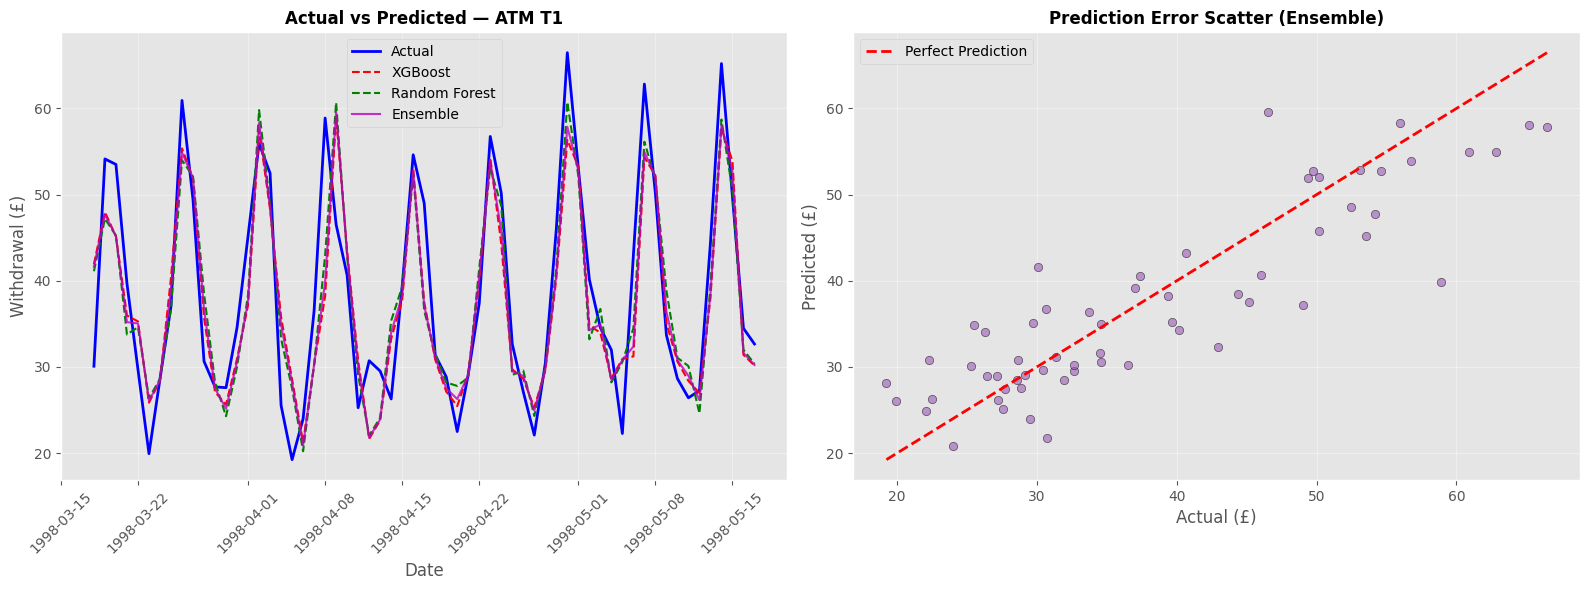

In [31]:
atm_diag = 'T1'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

t_xgb = test_xgb[test_xgb['ATM_ID'] == atm_diag]
t_rf = test_rf[test_rf['ATM_ID'] == atm_diag]
t_ens = test_ensemble[test_ensemble['ATM_ID'] == atm_diag]

axes[0].plot(t_xgb['Date'], t_xgb['Withdrawal'], 'b-', linewidth=2, label='Actual')
axes[0].plot(t_xgb['Date'], t_xgb['Predicted_Withdrawal'], 'r--', linewidth=1.5, label='XGBoost')
axes[0].plot(t_rf['Date'], t_rf['Predicted_Withdrawal'], 'g--', linewidth=1.5, label='Random Forest')
axes[0].plot(t_ens['Date'], t_ens['Predicted_Withdrawal'], 'm-', linewidth=1.5, alpha=0.8, label='Ensemble')
axes[0].set_title(f'Actual vs Predicted — ATM {atm_diag}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Withdrawal (£)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.4)

y_true = t_ens['Withdrawal']
y_pred = t_ens['Predicted_Withdrawal']
axes[1].scatter(y_true, y_pred, alpha=0.6, color='#9b59b6', edgecolor='k')
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Prediction Error Scatter (Ensemble)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual (£)')
axes[1].set_ylabel('Predicted (£)')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=300)
plt.show()

## 9. Conclusion

### Key Findings

1. **ARIMA** serves as a weak baseline — it cannot capture the strong weekly seasonality in ATM withdrawals.
2. **SARIMAX** significantly improves over ARIMA by modeling the 7-day cycle, but remains limited to a single ATM at a time.
3. **XGBoost** and **Random Forest** global models learn from all 111 ATMs simultaneously, leveraging calendar features, lag structures, and rolling statistics.
4. Feature importance analysis confirms that **recent withdrawal history** (lags and rolling averages) are the strongest predictors, followed by weekly cycle features.
